# Imports

In [1]:
import importlib
import sys

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')

# Data

### Load Data Files

In [2]:
# Path to your pickle file (saved with torch.save)
file_path_train = '../../../../encoded_data_conformance_v2/Helpdesk/helpdesk_all_3_train.pkl'
# Load the dataset using torch.load
helpdesk_train_dataset = torch.load(file_path_train, weights_only=False)

# Path to your pickle file (saved with torch.save)
file_path_val = '../../../../encoded_data_conformance_v2/Helpdesk/helpdesk_all_3_val.pkl'
# Load the dataset using torch.load
helpdesk_val_dataset = torch.load(file_path_val, weights_only=False)

### Train Data Insights

In [3]:
# Helpdesk dataset dynamic categories, features:
helpdesk_all_categories = helpdesk_train_dataset.all_categories

helpdesk_all_categories_cat = helpdesk_all_categories[0]
# print(helpdesk_all_categories_cat)
helpdesk_all_categories_num = helpdesk_all_categories[1]
# print(helpdesk_all_categories_num)
for i, cat in enumerate(helpdesk_all_categories_cat):
     print(f"Helpdesk dynamic categorical feature: {cat[0]}, Index position in categorical data list: {i}")
     print(f"Helpdesk amount of category labels: {cat[1]}")
print('\n')    
for i, num in enumerate(helpdesk_all_categories_num):
     print(f"Helpdesk dynamic numerical feature: {num[0]}, Index position in categorical data list: {i}")
     print(f"Helpdesk amount of numerical: {num[1]}")
print('\n')
     
# Helpdesk dataset static categories, features:
helpdesk_all_stat_categories = helpdesk_train_dataset.all_static_categories

helpdesk_all_stat_categories_cat = helpdesk_all_stat_categories[0]
# print(helpdesk_all_stat_categories_cat)
helpdesk_all_stat_categories_num = helpdesk_all_stat_categories[1]
# print(helpdesk_all_stat_categories_num)
for i, cat in enumerate(helpdesk_all_stat_categories_cat):
     print(f"Helpdesk static categorical feature: {cat[0]}, Index position in categorical data list: {i}")
     print(f"Helpdesk amount of category labels: {cat[1]}")
print('\n')    
for i, num in enumerate(helpdesk_all_stat_categories_num):
     print(f"Helpdesk static numerical feature: {num[0]}, Index position in categorical data list: {i}")
     print(f"Helpdesk amount of numerical: {num[1]}")  


Helpdesk dynamic categorical feature: Activity, Index position in categorical data list: 0
Helpdesk amount of category labels: 15
Helpdesk dynamic categorical feature: Resource, Index position in categorical data list: 1
Helpdesk amount of category labels: 24


Helpdesk dynamic numerical feature: case_elapsed_time, Index position in categorical data list: 0
Helpdesk amount of numerical: 1
Helpdesk dynamic numerical feature: event_elapsed_time, Index position in categorical data list: 1
Helpdesk amount of numerical: 1
Helpdesk dynamic numerical feature: day_in_week, Index position in categorical data list: 2
Helpdesk amount of numerical: 1
Helpdesk dynamic numerical feature: seconds_in_day, Index position in categorical data list: 3
Helpdesk amount of numerical: 1


Helpdesk static categorical feature: VariantIndex, Index position in categorical data list: 0
Helpdesk amount of category labels: 158
Helpdesk static categorical feature: seriousness, Index position in categorical data list:

### Input Features for Encoder and Decoder

In [4]:
# Create lists with name of Encoder features (input) and decoder features (input & output)
# Encoder features:
enc_feat_cat = []
enc_feat_num = []
for cat in helpdesk_all_categories_cat:
    enc_feat_cat.append(cat[0])
for num in helpdesk_all_categories_num:
    enc_feat_num.append(num[0])
enc_feat = [enc_feat_cat, enc_feat_num]
print("Input features encoder: ", enc_feat)

# Static encoder features:
stat_enc_feat_cat = []
stat_enc_feat_num = []
for cat in helpdesk_all_stat_categories_cat:
     stat_enc_feat_cat.append(cat[0])
for num in helpdesk_all_stat_categories_num:
     stat_enc_feat_num.append(num[0])
stat_enc_feat = [stat_enc_feat_cat, stat_enc_feat_num]
print("Input features static encoder: ", stat_enc_feat)

# Decoder features:
dec_feat_cat = ['Activity']
dec_feat_num = ['event_elapsed_time']
dec_feat = [dec_feat_cat, dec_feat_num]
print("Features decoder: ", dec_feat)

Input features encoder:  [['Activity', 'Resource'], ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day']]
Input features static encoder:  [['VariantIndex', 'seriousness', 'customer', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup'], []]
Features decoder:  [['Activity'], ['event_elapsed_time']]


# Model

In [5]:
import model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model
importlib.reload(model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model)
from model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

# Prediction decoder output sequence length
seq_len_pred = helpdesk_train_dataset.min_suffix_size

# Size hidden layer
hidden_size = 128

# Number of cells
num_layers = 4

# Fixed Dropout probability 
# Experiment with different values but be carefull with exploiting gradients:
dropout = 0.1

# Encoder Decoder model initialization
model = DropoutUncertaintyEncoderDecoderLSTM(data_set_categories=helpdesk_all_categories,
                                             enc_feat=enc_feat,
                                             dec_feat=dec_feat,
                                             seq_len_pred=seq_len_pred,
                                             hidden_size=hidden_size,
                                             num_layers=num_layers,
                                             dropout=dropout,
                                             # static attributes
                                             static_data_set_categories=helpdesk_all_stat_categories,
                                             static_enc_feat=stat_enc_feat
                                             )

Dynamic data set categories:  ([('Activity', 15, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'EOS': 4, 'INVALID': 5, 'Insert ticket': 6, 'RESOLVED': 7, 'Require upgrade': 8, 'Resolve SW anomaly': 9, 'Resolve ticket': 10, 'Schedule intervention': 11, 'Take in charge ticket': 12, 'VERIFIED': 13, 'Wait': 14}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Data set static categories:  ([('VariantIndex', 158, {'1': 1, '10': 2, '100': 3, '101': 4, '102': 5, '103': 6, '104': 7, '106': 8, '109': 9, '11': 10, '110': 11, '111': 12, '118': 13, '119': 1

# Loss Object Creation

In [6]:
import loss.losses
importlib.reload(loss.losses)
from loss.losses import Loss

loss_obj = Loss()

# Training Configuration

In [7]:
import trainer.trainer
importlib.reload(trainer.trainer)
from trainer.trainer import Trainer
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(comment="Full_Helpdesk_grad_pro_conf_check_v2")

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Start learning rate
learning_rate = 1e-5
weight_decay = 0

# Optimizer and Scheduler
optimizer = torch.optim.AdamW(params=model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=15, min_lr=1e-8)

# Epochs
num_epochs = 100

# Batches
batch_size = 128

# lambda for L2 (weight, bias, dropout) regularization
# regularization_term = 1.0/(2.0*batch_size)
regularization_term = 1e-4

# shuffle data
shuffle = True

# teacher forcing
max_teacher_forcing_value = 1.0
min_teacher_forcing_value = 0.0

optimize_values = {"regularization_term":regularization_term,
                   "optimizer":optimizer,
                   "scheduler": scheduler,
                   "epochs":num_epochs,
                   "mini_batches":batch_size,
                   "shuffle": shuffle,
                   "min_teacher_forcing_value":min_teacher_forcing_value,
                   "max_teacher_forcing_value":max_teacher_forcing_value}

suffix_data_split_value = helpdesk_train_dataset.min_suffix_size
print("Train seq length: ", suffix_data_split_value)

"""
GradNorm:
We disable it here to establish a baseline. Complexity (GradNorm) should only be added if the  baseline fails to learn certain tasks.
"""
# GradNorm parameter: 
use_gradnorm = True
# use_gradnorm = False
# task to be balanced for teacher forcing
number_tasks = len(dec_feat[0]) + len(dec_feat[1])
# Grdanorm hyperparams
# alpha: tasks/ alpha value (rule of thumb): 2-3: 1.0-1.5, 4-6: 0.7-1.0, 7-10: 0.4-0.7
# Formula approx: 2/sqrt(tasks)
gn_alpha = 1.5
# learning rate: Adjust relative to model learning rate.
gn_learning_rate = 1e-4

gradNorm = {"use_gradnorm":use_gradnorm,
            "number_tasks": number_tasks,
            "gn_alpha":gn_alpha,
            "gn_learning_rate": gn_learning_rate}
# gradNorm = None

trainer = Trainer(device=device,
                  model=model,
                  data_train=helpdesk_train_dataset,
                  data_val=helpdesk_val_dataset,
                  loss_obj=loss_obj,
                  log_normal_loss_num_feature = [],
                  optimize_values=optimize_values,
                  suffix_data_split_value=suffix_data_split_value,
                  writer=writer,
                  gradnorm_values=gradNorm,
                  save_model_n_th_epoch = 1,
                  saving_path = 'Helpdesk_full_grad_norm_pro_conf_check_v2.pkl')

# Train the model:
# - use stattics: (tensor) tensor of seperate encoded static attributes which is merged with dynmaics beforehand
# - use zero padd masking: (True) mask the left padded zeros in the encoder
# - use EOS padd masking: (True) mask the right padded unwanted EOS tokens in the loss
train_attenuated_losses, val_losses, val_attenuated_losses = trainer.train_model(use_statics=True,
                                                                                 use_zero_padd_masking=True,
                                                                                 use_eos_padd_masking=True)

Train seq length:  3
Device:  cuda
Model:  DropoutUncertaintyEncoderDecoderLSTM(
  (embeddings_enc): ModuleList(
    (0): Embedding(15, 7)
    (1): Embedding(24, 9)
  )
  (embeddings_static_enc): ModuleList(
    (0): Embedding(158, 27)
    (1): Embedding(2, 2)
    (2): Embedding(342, 42)
    (3): Embedding(22, 9)
    (4): Embedding(8, 5)
    (5-7): 3 x Embedding(5, 4)
    (8): Embedding(6, 4)
    (9): Embedding(5, 4)
  )
  (encoder): DropoutUncertaintyLSTMEncoder(
    (embeddings): ModuleList(
      (0): Embedding(15, 7)
      (1): Embedding(24, 9)
    )
    (static_embeddings): ModuleList(
      (0): Embedding(158, 27)
      (1): Embedding(2, 2)
      (2): Embedding(342, 42)
      (3): Embedding(22, 9)
      (4): Embedding(8, 5)
      (5-7): 3 x Embedding(5, 4)
      (8): Embedding(6, 4)
      (9): Embedding(5, 4)
    )
    (input_proj): Linear(in_features=125, out_features=128, bias=True)
    (layernorm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (act): ReLU()
    (fi

# Training Visualization

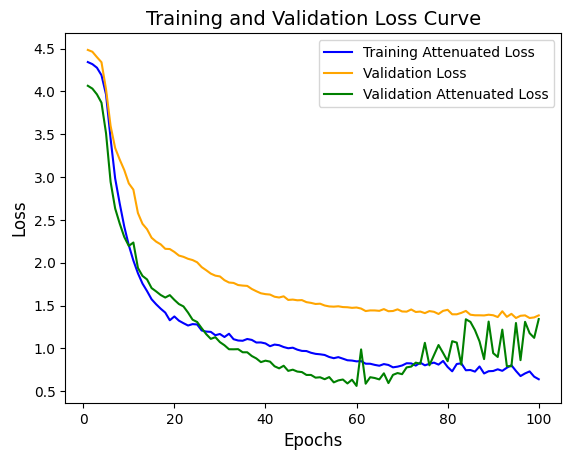

In [8]:
import matplotlib.pyplot as plt

# After training is finished, plot the loss curves
plt.plot(range(1, num_epochs+1), train_attenuated_losses, label='Training Attenuated Loss', color='blue')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', color='orange')
plt.plot(range(1, num_epochs+1), val_attenuated_losses, label='Validation Attenuated Loss', color='green')
# Labeling x and y axes
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
# Adding title
plt.title('Training and Validation Loss Curve', fontsize=14)
# Adding legend
plt.legend()
# Show the plot
plt.show()